# Computing the transition in the HANC model manually: partial equilibrium

In [ ]:
import numpy as np
import numba as nb
from consav.linear_interp import interp_1d_vec
import matplotlib.pyplot as plt
from consav.grids import equilogspace
from consav.markov import log_rouwenhorst

We compute a transition in the HANC model from last week. The calibration here is annual, so $\beta$, $\delta$ and the income process differ from last week's notebook.

In [ ]:
class Parameters:
    def __init__(self):
        # preferences
        self.beta = 0.9498866874132476
        self.sigma = 1.0

        # production
        self.alpha = 1/3
        self.delta = 0.1/3
        self.Gamma = 1.0

        # grids
        self.Na = 500
        self.a_min = 0.0
        self.a_max = 10_000.0
        self.a_grid = equilogspace(self.a_min,self.a_max,self.Na)

        # income
        self.rho_z = 0.95
        self.sigma_psi = 0.30*(1.0-self.rho_z**2.0)**0.5
        self.Nz = 7
        self.z_grid, self.z_trans,self.z_ergodic,_,_ = log_rouwenhorst(self.rho_z,self.sigma_psi,self.Nz)


par = Parameters()

## Previous code to compute the stationary equilibrium

First, we reuse some of the functions we wrote last week to solve the household block.

In [ ]:
"""
Household backward step
"""

def egm_ss(r, w, par, max_iter = 50_000, tol = 1e-12, verbose = False):
    """ solve the EGM for the steady state """

    # a. initialize
    y = w*par.z_grid
    c = r*par.a_grid[np.newaxis,:] + y[:,np.newaxis]
    Va = (1+r)*c**(-par.sigma)

    # b. iterate
    for it in range(max_iter):

        # i. solve backwards
        c, a, Va_new = solve_hh_backwards_one_step(par.z_trans, par.z_grid, par.a_grid, par.sigma, par.beta, r, w, Va)

        # ii. check convergence
        error = np.max(np.abs(Va - Va_new))
        if verbose:
            print(error)
        if error < tol:
            return c, a, Va_new

        Va = Va_new



def solve_hh_backwards_one_step(z_trans, z_grid, a_grid, sigma, beta, r, w, vbeg_a):

    # vbeg_a is the derivative of the value function at the beginning of the period
    Nz, Na = vbeg_a.shape
    a = np.zeros((Nz, Na))
    c = np.zeros((Nz, Na))

    # a. solve step
    for i_z in range(Nz):

        ## i. get c(a',z)
        c_endo = (beta*vbeg_a[i_z])**(-1/sigma)

        # ii. compute m_endo = c(a',z) + a'
        m_endo = c_endo + a_grid # current consumption + end-of-period assets

        # iii. interpolation to fixed grid
        m = (1+r)*a_grid + w*z_grid[i_z] # exogenous grid of coh
        interp_1d_vec(m_endo,a_grid,m,a[i_z]) # fill up the array a[i_z]
        a[i_z,:] = np.fmax(a[i_z,:],0.0) # enforce borrowing constraint
        c[i_z] = m-a[i_z]

    # b. expectation step
    RHS = (1+r)*c**(-sigma)
    vbeg_a_new = z_trans @ RHS

    return c, a, vbeg_a_new


In [ ]:
"""
Household forward step
"""

def get_lottery(a, a_grid):
    # step 1: find the i such that a' lies between gridpoints a_i and a_(i+1)
    a_i = np.searchsorted(a_grid, a, side='right') - 1
    a_i = np.clip(a_i, 0, len(a_grid)-2)

    # step 2: implement (8) to obtain lottery probabilities pi
    a_pi = (a_grid[a_i+1] - a)/(a_grid[a_i+1] - a_grid[a_i])

    return a_i, a_pi

@nb.njit
def forward_policy(D, a_i, a_pi):
    Dend = np.zeros_like(D)
    for e in range(a_i.shape[0]):
        for a in range(a_i.shape[1]):
            # send pi(e,a) of the mass to gridpoint i(e,a)
            Dend[e, a_i[e,a]] += a_pi[e,a]*D[e,a]

            # send 1-pi(e,a) of the mass to gridpoint i(e,a)+1
            Dend[e, a_i[e,a]+1] += (1-a_pi[e,a])*D[e,a]

    return Dend

@nb.njit
def forward_iteration(D, z_trans, a_i, a_pi):
    Dend = forward_policy(D, a_i, a_pi)
    return z_trans.T @ Dend

def distribution_ss(a, par, tol=1E-10):
    a_i, a_pi = get_lottery(a, par.a_grid)

    # as initial D, use stationary distribution for s, plus uniform over a
    D = par.z_ergodic[:, np.newaxis] * np.ones_like(par.a_grid) / len(par.a_grid)

    # now iterate until convergence to acceptable threshold
    for _ in range(100_000):
        D_new = forward_iteration(D, par.z_trans, a_i, a_pi)
        if np.max(np.abs(D_new - D)) < tol:
            return D_new
        D = D_new


In [ ]:
"""
Household block steady-state
"""

def household_ss(r, w, par, max_iter = 10_000, tol = 1e-8, verbose = False):
    c, a, Va = egm_ss(r, w, par, max_iter, tol, verbose)
    D = distribution_ss(a, par)
    A = np.sum(D * a)
    C = np.sum(D * c)
    return A, C, D, a, c, Va

In [ ]:
def find_ss_beta(beta, par):
    par.beta = beta
    r = 0.05
    w = 1-par.alpha
    K = 4
    A, _, _, _, _, _  = household_ss(r, w, par)
    print(A-K)
    return A-K

from scipy.optimize import brentq
par.beta = brentq(find_ss_beta, 0.9, 0.952, args=(par,))

r_ss = 0.05
Y_ss = 1
K_ss = 4
par.alpha = 1/3
par.Gamma = Y_ss /(K_ss**par.alpha)
par.delta = par.alpha * par.Gamma * K_ss**(par.alpha-1) - r_ss
w_ss = (1-par.alpha) * Y_ss
A_ss, C_ss, D_init, a_ss, c_ss, Va_term = household_ss(r_ss, w_ss, par)

-3.9999999999999987


18.85097130114365
-3.9999999999999964
-3.9754237154914476
-3.6903026999917037
-2.764996557364749
-0.8924888421929031


1.3487170555343209
-0.2148552940458055
0.009983083845268581
-0.00043326116878583676


-8.180241124478016e-07
2.2041035663278308e-11
-1.8816908031737967e-09


## Partial equilibrium transition

In a heterogeneous-agent model, we need to compute the policy functions and the distribution when the households face a **path of prices** $(w_t,r_t)_{t\geq 0}$. 

Important assumptions: 
- Initial conditions: we compute the transition from a given distribution $D_0$ that we already know
- Terminal condition: we compute a transition towards some stationary state where we know the value function (or its derivative)

It is useful to distinguish two types of transitions:
- Transitory ones: both the initial and terminal conditions are the steady-state values 
- Permanent ones: the economy moves from one state to another state (the terminal state must be a stationary one)

Once we have picked up a $D_0$ and $Va_T$, we can compute the transition for a given path of prices $(w_t,r_t)_{t=0}^T$ in two steps:

1. **Backward step:** for every period $t$ in $(T,0)$, solve the problem of the household $V_t(a_t,z_t)=\max u(c_t)+\beta \mathbb{E}_t[V_{t+1}(a_{t+1},z_{t+1})]$ **backward in time** and obtain the **time-varying** policy functions $a_t(a,z)$ and $c_t(a,z)$ (using our terminal condition)
2. **Forward step:** for every period $t$ in $(0,T)$ use the policy functions to update the distribution over time, using the histogram method 

**Question**: *Can you figure out why we call this a perfect foresight transition? Where is this assumption baked-in?*

For the sake of simplicity, we will use the stationary equilibrium we just computed, and see what happens if we increase arbitrarily wages by 1% at period $t=0$.

First, let's do the backward step. We initialize the algorithm with our terminal condition, and then apply the EGM step for every $t\in(T,0)$, 

In [7]:
T = 1000
r_vec = np.ones((T)) * r_ss
w_vec = np.ones((T)) * w_ss
w_vec[0] = w_vec[0] * 1.01


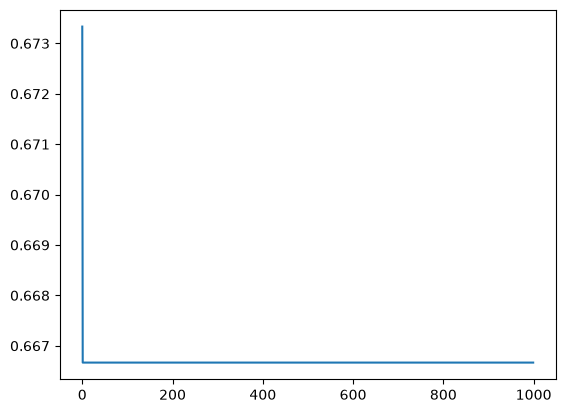

In [8]:
plt.plot(w_vec)

In [ ]:

a_trans = np.zeros((T, par.Nz, par.Na))
c_trans = np.zeros((T, par.Nz, par.Na))
Va_trans = Va_term.copy() # Terminal condition

for t in reversed(range(T)):
    c_trans[t], a_trans[t], Va_trans = solve_hh_backwards_one_step(par.z_trans,
                                                                   par.z_grid,
                                                                   par.a_grid,
                                                                   par.sigma,
                                                                   par.beta,
                                                                   r_vec[t],
                                                                   w_vec[t],
                                                                   Va_trans)
    # note that w_vec[t] and r_vec[t] are time-varying
    # note that Va_trans is updated every iteration

print(a_trans.shape)
print(c_trans.shape)
# note the new dimensions of the policy functions: first dimension is time.

(1000, 7, 500)
(1000, 7, 500)


And we have obtained our policy functions! 

**Questions**: take 5 minutes to read the code above.

- What does `reversed(range(T))` does? Why do we need it?
- For every period, where do we compute the next period derivative of the value function? How is it updated? 
- Why do we start with `Va_trans = Va_term.copy()`?
- What is the size of `r_vec` and `w_vec`? What is the size of `c_trans` and `a_trans`?

We can now use our forward step algorithm to compute the change in the distribution over time.

In [ ]:
D_trans = np.zeros((T, par.Nz, par.Na))
D_trans[0] = D_init

for t in range(T-1):
    a_i, a_pi = get_lottery(a_trans[t], par.a_grid)
    D_trans[t+1] = forward_iteration(D_trans[t], par.z_trans, a_i, a_pi)

For clarity, we can put this code in a function, with a `@nb.njit` decorator to speed things up a little.

In [11]:
@nb.njit
def forward_iteration_trans(D_init, z_trans, a_i, a_pi, T):
    Nz, Na = D_init.shape
    D = np.zeros((T, Nz, Na))
    D[0] = D_init
    for t in range(T-1):
        D[t+1] = forward_iteration(D[t], z_trans, a_i[t], a_pi[t])
    return D

We now have the policy functions and the distribution, and we can obtain aggregate values by summing over the two last dimensions.

In [12]:
A_trans = np.sum(D_trans * a_trans, axis = (1,2)) # axis = (1,2) means sum over the dimensions 1 and 2 but keep dimension 0
C_trans = np.sum(D_trans * c_trans, axis = (1,2))

**Questions** 

- Why do we need to set `D_trans[0] = D_init`? 
- What is the size of `D_trans`? `A_trans`? `C_trans`? 

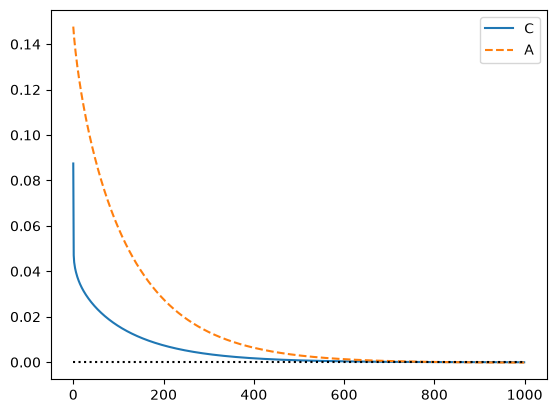

In [13]:
plt.plot(100*(C_trans-C_ss)/C_ss, label = 'C')
plt.plot(100*(A_trans-A_ss)/A_ss, label = 'A', linestyle = '--')
plt.plot(np.zeros_like(A_trans), linestyle = ':', color = 'black')
plt.legend()
plt.show()

Let's put those two steps together, and we obtain a function that takes as inputs:
1. A terminal condition `Va_term`
2. An initial condition `D_init` 
3. A vector of time-varying interest rate 
4. A vector of time-varying wages 

and some parameters. This is enough to compute a **partial-equilibrium** transition of the household block: given some prices, what will be the policy functions, distribution, and the aggregate values of households?

In [ ]:
def get_impulse_response(Va_term, D_init, r_vec, w_vec, par):
    T = r_vec.size

    # backward step
    a_trans = np.zeros((T, par.Nz, par.Na))
    c_trans = np.zeros((T, par.Nz, par.Na))
    Va_trans = Va_term.copy() # important!
    for t in reversed(range(T)):
        c_trans[t], a_trans[t], Va_trans = solve_hh_backwards_one_step(par.z_trans,
                                                                       par.z_grid,
                                                                       par.a_grid,
                                                                       par.sigma,
                                                                       par.beta,
                                                                       r_vec[t],
                                                                       w_vec[t],
                                                                       Va_trans)

    # forward step
    a_i, a_pi = get_lottery(a_trans, par.a_grid)

    D_trans = forward_iteration_trans(D_init, par.z_trans, a_i, a_pi, T)
    A_trans = np.sum(D_trans * a_trans, axis = (1,2))
    C_trans = np.sum(D_trans * c_trans, axis = (1,2))

    return C_trans, A_trans, D_trans, c_trans, a_trans

**Exercise:** compute a transition following a shock on $r$ at $t=20$, and plot your results 

In [ ]:
# Code here
r_shock = # ?
r_vec = # ?
w_vec = # ?

# impose the shock

# compute impulse reponse

plt.plot((A_trans-A_ss) / A_ss * 100, label = 'A')
plt.plot((C_trans-C_ss) / C_ss * 100, label = 'C', linestyle = ':')
plt.legend()
plt.show()

**Solution**    

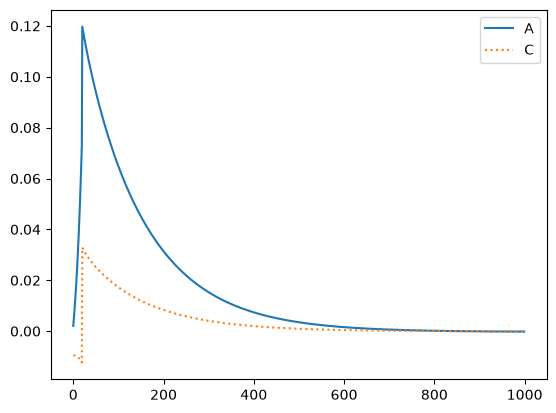

In [ ]:
# Code here
r_shock = r_ss * (1.01)
r_vec = np.ones((T)) * r_ss
w_vec = np.ones((T)) * w_ss

r_vec[20] = r_shock

C_trans, A_trans, D_trans, c_trans, a_trans = get_impulse_response(Va_term, D_init, r_vec, w_vec, par)

plt.plot((A_trans-A_ss) / A_ss * 100, label = 'A')
plt.plot((C_trans-C_ss) / C_ss * 100, label = 'C', linestyle = ':')
plt.legend()
plt.show()